In [1]:
__nbid__ = '0082'  # ID of this notebook in the DL NB collection
__author__ = 'Stephanie Juneau <stephanie.juneau@noirlab.edu>'
__version__ = '20260408'  # yyyymmdd
__datasets__ = ['sdss_dr17']
__keywords__ = ['sdss spectra', 'spectrum stacking', 'sparcl', 'stars', 'galaxies']

# Stacking SDSS Spectra of Stars and Galaxies Selected by Color

*Stéphanie Juneau (NOIRLab), Ragadeepika Pucha (U.Arizona) & The Astro Data Lab Team*

### Table of contents
* [Goals & Summary](#goals)
* [Disclaimer & attribution](#attribution)
* [Imports & setup](#imports)
* [Part I: Stars](#stars)
    * [Data retrieval](#data)
    * [Color-color diagram](#colors)
    * [Helper functions](#functions)
    * [Stacking stellar spectra](#stacking)
* [Part II: Galaxies](#galaxies)
    * [Data retrieval](#data_gal)
    * [Color-color diagram](#colors_gal)
    * [Stacking galaxy spectra](#stacking_gal)
* [Resources](#resources)

<a class="anchor" id="goals"></a>
# Goals

In this notebook, we will show how to access and plot spectra of stars and of galaxies from SDSS in bins of optical colors. The spectra will be retrieved using [SPARCL](https://astrosparcl.datalab.noirlab.edu/sparc/) (SPectral Analysis and Retrievable Catalog Lab) and then stacked to create composite spectra with increased signal-to-noise.

## Steps
1. Query the SDSS DR17 spectroscopic catalog for stars with good signal-to-noise
2. Compute optical colors (g−r, r−z) and visualize the stellar locus (Part I) or galaxy locus (Part II)
3. Select stars (Part I) or galaxies (Part II) in bins of g−r color
4. Retrieve and stack spectra per bin to reveal average spectral features

# Summary

Stellar spectra are important to identify the stellar type and infer physical properties. Large surveys like SDSS and DESI have obtained spectra for millions of stars. Using SDSS data hosted at Astro Data Lab and SPARCL, we demonstrate how to search for stars based on their photometric colors -- or their spectral type -- then retrieve and stack their spectra directly from a Jupyter notebook.

Stacking spectra improves the signal-to-noise ratio, revealing clear spectral features that characterize stellar populations across the color sequence. While the color variation is gradual when directly selecting by the observed `g-r` color, the variation per spectral type is more pronounced.

In Part II, we repeat a similar analysis but for galaxies instead of stars.

<a class="anchor" id="attribution"></a>
# Disclaimer & attribution

Disclaimers
-----------
Note that using the Astro Data Lab constitutes your agreement with our minimal [Disclaimers](https://datalab.noirlab.edu/disclaimers.php).

Acknowledgments
---------------
If you use **Astro Data Lab** in your published research, please include the text in your paper's Acknowledgments section:

_This research uses services or data provided by the Astro Data Lab, which is part of the Community Science and Data Center (CSDC) Program of NSF NOIRLab. NOIRLab is operated by the Association of Universities for Research in Astronomy (AURA), Inc. under a cooperative agreement with the U.S. National Science Foundation._

If you use **SPARCL jointly with the Astro Data Lab platform** (via JupyterLab, command-line, or web interface) in your published research, please include this text below in your paper's Acknowledgments section:

_This research uses services or data provided by the SPectra Analysis and Retrievable Catalog Lab (SPARCL) and the Astro Data Lab, which are both part of the Community Science and Data Center (CSDC) Program of NSF NOIRLab. NOIRLab is operated by the Association of Universities for Research in Astronomy (AURA), Inc. under a cooperative agreement with the U.S. National Science Foundation._

In either case **please cite the following papers**:

* Data Lab concept paper: Fitzpatrick et al., "The NOAO Data Laboratory: a conceptual overview", SPIE, 9149, 2014, https://doi.org/10.1117/12.2057445

* Astro Data Lab overview: Nikutta et al., "Data Lab - A Community Science Platform", Astronomy and Computing, 33, 2020, https://doi.org/10.1016/j.ascom.2020.100411

If you are referring to the Data Lab JupyterLab / Jupyter Notebooks, cite:

* Juneau et al., "Jupyter-Enabled Astrophysical Analysis Using Data-Proximate Computing Platforms", CiSE, 23, 15, 2021, https://doi.org/10.1109/MCSE.2021.3057097

If publishing in a AAS journal, also add the keyword: `\facility{Astro Data Lab}`

And if you are using SPARCL, please also add `\software{SPARCL}` and cite:

* Juneau et al., "SPARCL: SPectra Analysis and Retrievable Catalog Lab", Conference Proceedings for ADASS XXXIII, 2024
https://doi.org/10.48550/arXiv.2401.05576

The NOIRLab Library maintains [lists of proper acknowledgments](https://noirlab.edu/science/about/scientific-acknowledgments) to use when publishing papers using the Lab's facilities, data, or services.

<a class="anchor" id="imports"></a>
# Imports and setup

In [2]:
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colormaps
from collections import Counter

from dl import queryClient as qc
from sparcl.client import SparclClient

In [3]:
# Publication-quality plot settings
matplotlib.rc('font', size=18)
matplotlib.rc('axes', linewidth=2.0)
matplotlib.rc('xtick', top=True, direction='in')
matplotlib.rc('ytick', right=True, direction='in')
matplotlib.rc('xtick.major', size=6.0)
matplotlib.rc('xtick.minor', size=4.0)
matplotlib.rc('ytick.major', size=6.0)
matplotlib.rc('ytick.minor', size=4.0)

In [4]:
# Initialize the SPARCL client (no login required for public data)
client = SparclClient()

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


<a class="anchor" id="stars"></a>
# Part I: Stars

The first part of this notebook will focus on stellar spectra.

<a class="anchor" id="data"></a>
## Data retrieval

We query the SDSS DR17 spectroscopic catalog (`sdss_dr17.specobj`) at Astro Data Lab to select stars with good signal-to-noise ratios. The selection criteria are:

- `class = 'STAR'`: spectroscopically classified as a star
- `zwarning = 0`: no redshift warnings (reliable classification)
- `instrument = 'SDSS'`: observed with the original SDSS spectrograph
- `sn1_g > 5` and `sn1_r > 5`: signal-to-noise ratio > 5 in both g and r bands
- `spectroflux_{g,r,z} > 0`: positive values of flux in g, r, z bands

In [5]:
query = """
    SELECT specobjid, z, subclass, snmedian,
           spectroflux_g, spectroflux_r, spectroflux_z,
           sn1_g, sn1_r, elodieteff, elodiez, elodiesptype
    FROM sdss_dr17.specobj
    WHERE (class='STAR' AND zwarning=0 AND instrument='SDSS'
           AND sn1_g>5 AND sn1_r>5 
           AND spectroflux_g>0 AND spectroflux_r>0 AND spectroflux_z>0)
"""

t = qc.query(sql=query, fmt='table')
print(f"Number of stars retrieved: {len(t)}")
t[:5]

Number of stars retrieved: 496101


specobjid,z,subclass,snmedian,spectroflux_g,spectroflux_r,spectroflux_z,sn1_g,sn1_r,elodieteff,elodiez,elodiesptype
int64,float64,str12,float64,float64,float64,float64,float64,float64,int64,float64,str10
2889072702671316992,-0.00021731299,G2,29.051205,37.716625,71.17299,105.57261,86.3617,93.0679,6000,-0.00024435754,unknown
2877815347283519488,-0.00011563041,K1,45.59557,278.05368,666.0655,1082.0731,65.4451,151.876,5294,-0.00011003733,K0V
2877824143376541696,-1.4220168e-05,F9,51.21606,728.35095,1377.1919,1974.7937,65.4451,151.876,5929,-5.009388e-06,F8
2889071053403875328,-0.0003154584,F9,14.6928425,12.814167,27.79252,46.310158,86.3617,93.0679,5285,-0.00031283422,G8V
2889071603159689216,-0.00020386753,F9,17.90087,23.913109,46.790535,72.83488,86.3617,93.0679,6000,-0.00018224867,unknown


In [6]:
# Compute optical colors from spectrophotometric fluxes
t['g_r'] = -2.5 * np.log10(t['spectroflux_g'] / t['spectroflux_r'])
t['r_z'] = -2.5 * np.log10(t['spectroflux_r'] / t['spectroflux_z'])

r_z = t['r_z']
g_r = t['g_r']

In [7]:
# Print a list of example spectral types --> we will write a function to extract 
# a "simple" type along the sequence OBAFGKM
print(np.unique(t['elodiesptype']))

elodiesptype
------------
           0
          A0
      A0p...
     A0sp...
    A0spe...
         A1V
          A2
         A2V
      A2pvar
          A3
         ...
         M2V
      M2Vvar
         M3V
          O8
   O9.5Ib...
    O9.5Vvar
        S...
        sdF3
        sdF8
        sdG2
     unknown
Length = 177 rows


<a class="anchor" id="colors"></a>
## Color-color diagram

We visualize all stars in g−r vs. r−z color space. Stars trace a well-defined **stellar locus** that reflects their effective temperatures: hot blue stars (low g−r) sit at the bottom left, while cool red stars (high g−r) sit at the top right.

The red lines mark the color region we select for spectral stacking: r−z between −0.3 and 0.7, and g−r between −0.1 and 1.2. Within this region we define 8 bins of width 0.1 mag in g−r.

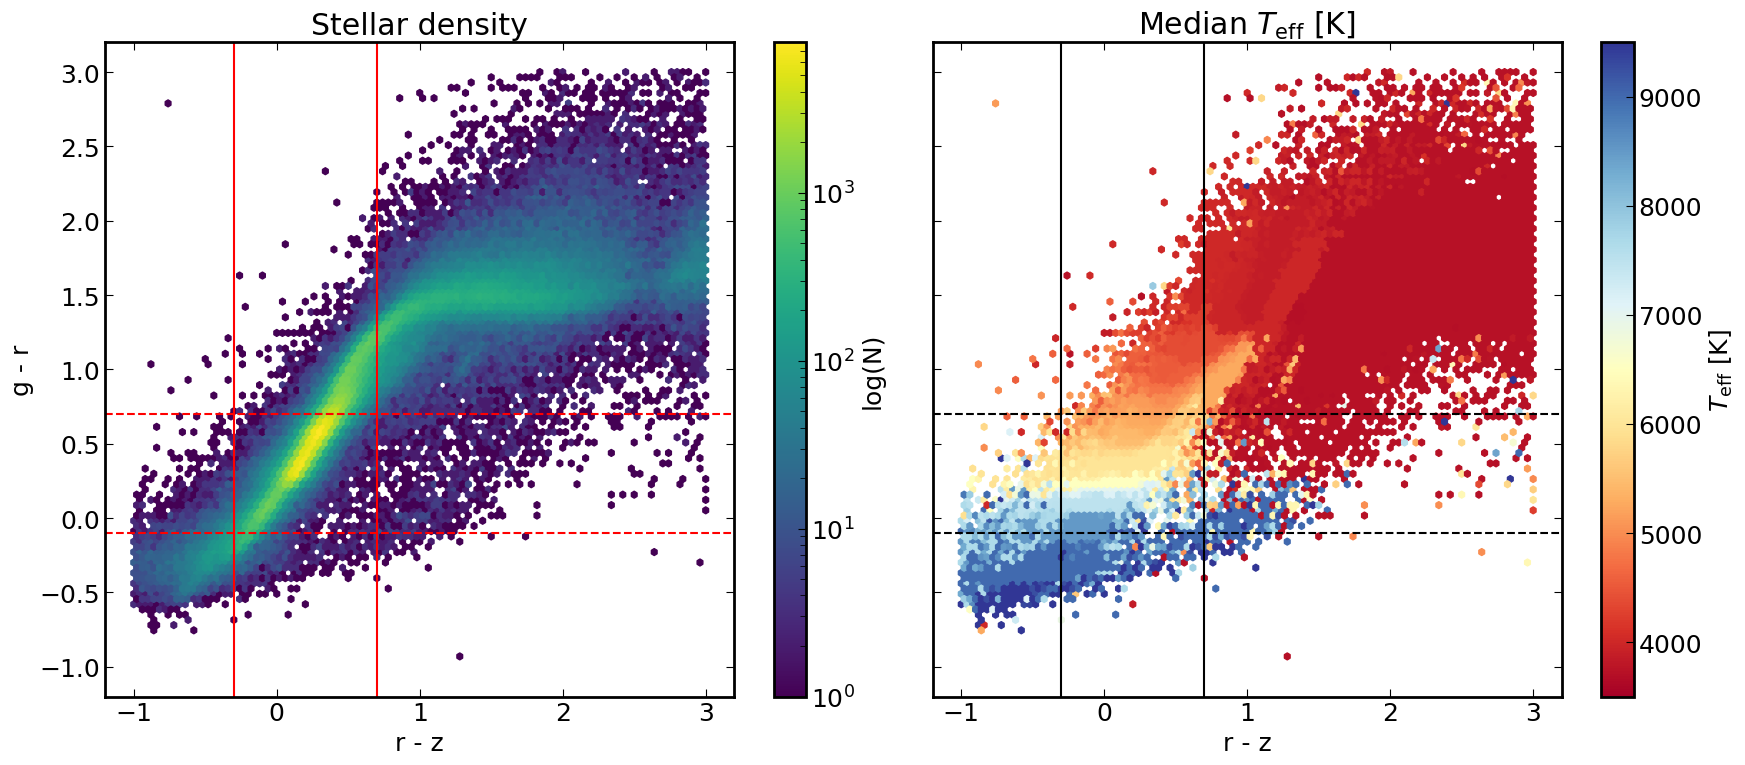

In [8]:
# Selection boundaries
r_z_min, r_z_max = -0.3, 0.7
g_r_min, g_r_max = -0.1, 0.7
Nbins = 8
g_r_bin = (g_r_max - g_r_min)/Nbins   # bin width in g-r (in mag)

# Stars inside the selection range in r-z (vertical lines)
keep = (r_z >= r_z_min) & (r_z < r_z_max)

# Figure: two-panel color-color diagram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# --- Left panel: stellar density ---
im1 = ax1.hexbin(r_z, g_r, bins='log', cmap='viridis',
                 mincnt=1, extent=(-1, 3, -1, 3))
ax1.set_xlabel('r - z')
ax1.set_ylabel('g - r')
ax1.set_title('Stellar density')
plt.colorbar(im1, ax=ax1, label='log(N)')

# --- Right panel: median effective temperature per bin ---
im2 = ax2.hexbin(r_z, g_r, C=t['elodieteff'], reduce_C_function=np.median,
                 cmap='RdYlBu', mincnt=1, extent=(-1, 3, -1, 3), 
                 vmin=3500, vmax=9500)
ax2.set_xlabel('r - z')
ax2.set_yticklabels([])   # shared axis — suppress repeated labels
ax2.set_title('Median $T_\mathrm{eff}$ [K]')
plt.colorbar(im2, ax=ax2, label='$T_\mathrm{eff}$ [K]')

# Mark the selection region on both panels
for ax, color in zip((ax1, ax2), ('r', 'k')):
    ax.axvline(r_z_min, color=color)
    ax.axvline(r_z_max, color=color)
    ax.axhline(g_r_min, color=color, ls='--')
    ax.axhline(g_r_max, color=color, ls='--')

plt.tight_layout()

<a class="anchor" id="functions"></a>
## Helper functions

We define functions for the notebook:

1. **`get_simple_sptype`** - extract the OBAFGKM letter from an ELODIE spectral type string
2. **`stack_spectra`** — retrieve, align and stack multiple SDSS spectra onto a common wavelength grid
3. **`plot_stacked_spectra_color(N)`** - stack and plot SDSS spectra for N randomly selected objects (stars or galaxies) per g-r color bin
4. **`plot_stacked_spectra_sptype(N)`** - stack and plot SDSS spectra for N randomly selected stars per spectral type


In [9]:
def get_simple_sptype(sptype_str):
    """
    Extract the OBAFGKM letter from an ELODIE spectral type string.
    Returns None for unclassified entries ('0', 'unknown'), subdwarfs
    ('sdX'), or types outside OBAFGKM.
    """
    s = str(sptype_str).strip()
    if s in ('0', 'unknown', '') or s.startswith('sd'):
        return None
    letter = s[0]
    return letter if letter in SPTYPES else None

In [10]:
def stack_spectra(table, return_number=False):
    """
    Function to Stack the spectra of all the sources in the given table.
    Uses SPARCL to retrieve spectra
    
    Returns an inverse variance weighted mean of the input spectra.
    
    Parameters
    ----------
    table : table
        Table of sources whose spectra need to be stacked
    
    Returns
    -------
    wavelength_stack : array
        Wavelength array of the stacked spectra
        
    flux_stack : array
        Flux array of the stacked spectra
    
    model_stack : array
        Model array of the stacked spectra

    n_stack : array
        If return_number = True 
    
    """
    
    # Create an array with the targeted loglam values - reference array
    loglam_ref = np.arange(3.5000, 3.9001, 0.0001).astype('float32')
    
    # Create empty lists for flux, ivar and model - 
    flux_array = []
    model_array = []
    ivar_array = []
    
    # Extract the necessary columns from the table
    # redshift = table['z']
    specobjid = [int(s) for s in table['specobjid'].data]
    
    # Number of spectra - 
    n = len(table)
    
    ## Retrieve the spectra
    res = client.retrieve_by_specid(specid_list = specobjid, 
                                    include = ['sparcl_id', 'specid', 'redshift', 'flux', 'wavelength', 'model', 'ivar'],
                                    dataset_list = ['SDSS-DR17'])
    
    ## All the spectra have the same spacing in log wavelength.
    ## We shift the spectra in the observed wavelength range to fill the same log wavelength range
    ## Join the different arrays of the individual spectra into a single array
    
    ## Compared the number of retrieved spectra to the number of requested spectra
    ## NOTE: some datasets have missing spectra with inconsistent data models, which will be added at the 
    ##       next re-ingestion. Stats available here: https://astrosparcl.datalab.noirlab.edu/sparc/datasetnotes/
    n_res = res.count
    n_use = np.min([n_res, n])
    if n_res!=n:
        print(f"WARNING: {n_res} spectra were retrieved from the requested {n}! Will proceed with {n_use} spectra.")
        
    for ii in range(n_use):   
                
        ## Get rest-frame spectra of each object
        res_rec = res.records[ii]
        z = res_rec.redshift
        lam = res_rec.wavelength/(1+z)
        flux = res_rec.flux*(1+z)
        model = res_rec.model*(1+z)
        ivar = res_rec.ivar/((1+z)**2)
        
        loglam = np.around(np.log10(lam), 4).astype('float32')
        # The log of reference wavelength and log of wavelength range of each spectra are converted to 'float32'
        # This helps in avoiding the rounding errors
        
        # Creating empty arrays for flux, inverse variance and model 
        # with the same length as the reference loglam array
        fl = np.zeros(len(loglam_ref))
        iv = np.zeros(len(loglam_ref))
        ml = np.zeros(len(loglam_ref))
        
        # Truth_array - A Boolean array which will define what pixels the spectra have been shifted to
        truth_array = np.zeros(len(loglam_ref), dtype = bool)
        
        # Find common elements between the reference and spectra wavelengths - 
        ll_common = np.intersect1d(loglam_ref, loglam)
        
        # Finding the indices of the first pixel in the common array in both reference and spectrum arrays
        ref_start = np.where(loglam_ref == ll_common[0])[0][0]
        spec_start = np.where(loglam == ll_common[0])[0][0]
        
        m = min(len(loglam_ref[ref_start:]), len(loglam[spec_start:]))
        
        # Match the first pixel of the common loglam values with the reference array 
        # Mark the number of pixels with the spectra starting from the first pixel to be True
        truth_array[ref_start:ref_start+m] = True

        # Fill the flux, inverse variance and model arrays
        fl[truth_array] = flux[spec_start:spec_start+m]
        iv[truth_array] = ivar[spec_start:spec_start+m]
        ml[truth_array] = model[spec_start:spec_start+m]
        
        # Where the reference array is empty, fill the flux and model with nan values
        # Set inverse variance to zero for these pixels
        fl[~truth_array] = np.nan
        iv[~truth_array] = 0.0
        ml[~truth_array] = np.nan
        
        # Create a masked array with 'nan' values marked
        # This avoids the pixels filled with 'nan' when stacking
        fl = np.ma.masked_array(fl, np.isnan(fl))
        iv = np.ma.masked_array(iv, np.isnan(iv))
        ml = np.ma.masked_array(ml, np.isnan(ml))

        # Normalization factor for individual spectra
        norm = np.ma.median(fl[(loglam_ref>np.log10(6700))&(loglam_ref<np.log10(6900))])

        flux_array.append(fl/norm)  #normalized
        model_array.append(ml)
        ivar_array.append(iv)
        
    # Stack the spectra by weighted average 
    wavelength_stack = 10**(loglam_ref)
    flux_stack = np.ma.average(flux_array, axis = 0) #, weights = ivar_array)
    model_stack = np.ma.average(model_array, axis = 0) #, weights = ivar_array)

    # Count how many spectra per spectral element
    number_stack = np.ma.sum((np.array(ivar_array)>0).astype('int'), axis = 0)
    
    flux_stack = flux_stack.filled(np.nan)
    model_stack = model_stack.filled(np.nan)
    
    if return_number==False:
        return (wavelength_stack, flux_stack, model_stack)
    else:
        return (wavelength_stack, flux_stack, model_stack, number_stack)

In [11]:
def plot_stacked_spectra_color(n, tab, colors, color_min, color_max, nbins,
                               mask=None, color_label='g-r', yscale='linear', 
                               xlim=(3750, 6800), ylim=(0.1, 3.6), x_label=4700, y_label=3.2):
    """
    Stack and plot spectra for N randomly selected objects per color bin.

    Parameters
    ----------
    n : int
        Number of spectra to stack per bin. Uses all available if fewer than n.
    tab : table
        Catalog table containing specobjid and z columns.
    colors : array
        Color array used for binning (e.g., g-r).
    color_min : float
        Minimum value of the color range to be considered
    color_max : float
        Maximum value of the color range to be considered.
    nbins : int
        Number of color bins.
    mask : boolean array, optional
        Pre-selection mask on the table (e.g. an r-z cut). Default: all objects.
    color_label : str, optional
        Color name used in the legend label. Default: 'g-r'.
    """
    if mask is None:
        mask = np.ones(len(tab), dtype=bool)

    norm_col = matplotlib.colors.Normalize(vmin=0, vmax=nbins)
    cmap = colormaps['Spectral_r']

    fig, ax = plt.subplots(1, 1, figsize=(12, 7))

    # Color bin size
    color_bin = (color_max - color_min) / nbins
    
    for i in range(nbins):
        sel = mask & (colors >= (color_min + i*color_bin)) \
                   & (colors <  (color_min + (i+1)*color_bin))
        n_avail = len(tab[sel])
        if n_avail == 0:
            print(f"Skipping bin {i+1}: no objects found.")
            continue
        if n_avail < n:
            print(f"Warning: bin {i+1} has only {n_avail} objects (requested {n}). "
                  f"Using all {n_avail}.")
            ind_n = list(range(n_avail))
        else:
            ind_n = random.sample(list(range(n_avail)), n)

        tab_sel = tab[sel][ind_n]
        lam_i, flux_i, model_i = stack_spectra(tab_sel)

        rgba_color = cmap(norm_col(i))
        center = color_min + i*color_bin + color_bin/2
        label_i = f"${color_label}$ = {center:.2f}"
        norm_val = np.nanmedian(flux_i[(lam_i > 6700) & (lam_i < 6900)])
        ax.plot(lam_i, flux_i / norm_val, color=rgba_color, label=label_i)

    leg = ax.legend(fontsize=16)
    for line in leg.get_lines():
        line.set_linewidth(3)

    ax.set_yscale(yscale)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('Wavelength [Angstrom]')
    ax.set_ylabel('$F_{\lambda}$ [normalized]')
    ax.text(x_label, y_label, f'N={n} per bin', fontsize=20)
    plt.tight_layout()

In [12]:
def plot_stacked_spectra_sptype(N):
    """
    Stack and plot SDSS spectra per spectral type bin (OBAFGKM sequence,
    hot to cool), using the pre-computed 'sptype' column.

    Parameters
    ----------
    N : int
        Number of spectra to randomly select and stack per spectral type.
        If fewer than n stars are available for a given type, all available
        stars are used and a warning is printed.
    """
    norm_col = matplotlib.colors.Normalize(vmin=0, vmax=len(SPTYPES) - 1)
    cmap = colormaps['Spectral_r']

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    yoffset = 0.2
    
    for i, sp in enumerate(SPTYPES):
        sel = np.where(t['sptype'] == sp)[0]
        n_avail = len(sel)

        if n_avail == 0:
            print(f"Skipping type {sp}: no stars found.")
            continue
        if n_avail < N:
            print(f"Warning: type {sp} has only {n_avail} stars (requested {N}). Using all {n_avail}.")
            ind_n = list(sel)
        else:
            ind_n = random.sample(list(sel), N)

        tab_sel = t[ind_n]

        lam_i, flux_i, model_i = stack_spectra(tab_sel)

        rgba_color = cmap(norm_col(i))
        norm_val = np.nanmedian(flux_i[(lam_i > 6750) & (lam_i < 6900)])
        ax.plot(lam_i, flux_i / norm_val + (len(SPTYPES)-i)*yoffset, color=rgba_color, label=f'{sp}  (N={len(ind_n)})')

    leg = ax.legend(fontsize=16, loc='upper right', title='Sp. type')
    for line in leg.get_lines():
        line.set_linewidth(3)

    ax.set_xlim([3750, 6900])
    ax.set_ylim([-0.1, 7.5])
    ax.set_xlabel('Wavelength [Angstrom]')
    ax.set_ylabel('$F_{\lambda}$ [normalized]')
    ax.text(4700, 6.2, f'N={N} per bin', fontsize=22)
    plt.tight_layout()

<a class="anchor" id="stacking"></a>
## Stacking stellar spectra by color

Stacking (co-adding) many spectra dramatically increases the signal-to-noise ratio and reveals faint features that are buried in noise in individual spectra. We stack N randomly selected stars from each g−r color bin and normalize each stack by its median flux in the 6700–6900 Å continuum window.

The color sequence runs from hot blue stars (g−r ≈ −0.05, **purple**) to cool red stars (g−r ≈ 0.65, **red**), following the `Spectral_r` colormap.

**Approximate run times:**
- N = 5 per bin: ~3 seconds
- N = 500 per bin: ~1.5 minutes

In [13]:
norm_col = matplotlib.colors.Normalize(vmin=0, vmax=Nbins)
cmap = colormaps['Spectral_r']

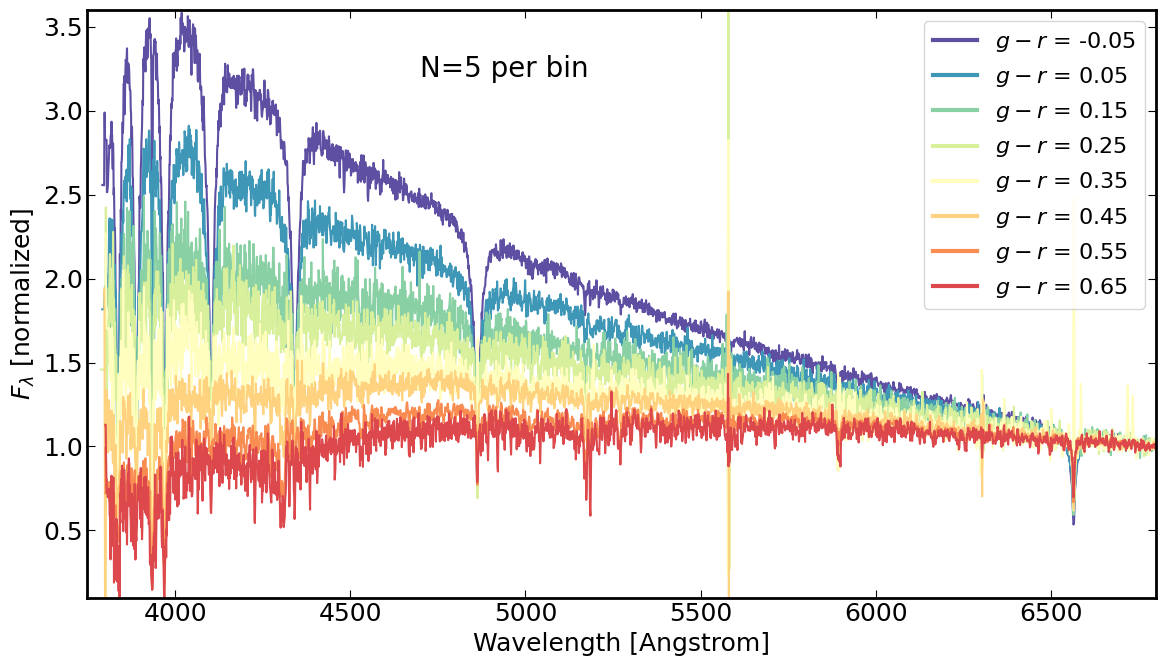

In [14]:
# Figure 1a: stacked spectra with N=5 per bin (~3 seconds)
plot_stacked_spectra_color(5, tab=t, colors=g_r, color_min=g_r_min, color_max=g_r_max,
                           nbins=Nbins, mask=keep)

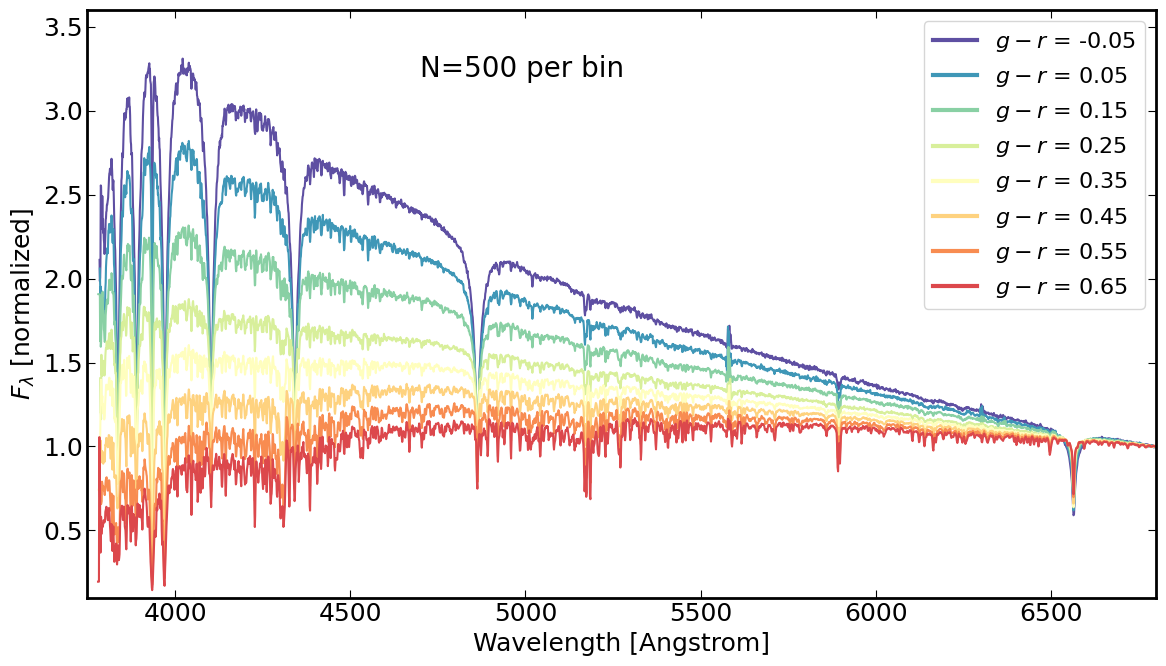

In [15]:
# Figure 1b: stacked spectra with N=500 per bin (~1.5 minutes)
plot_stacked_spectra_color(500, tab=t, colors=g_r, color_min=g_r_min, color_max=g_r_max,
                           nbins=Nbins, mask=keep)

## Stacking stellar spectra by spectral type

Similarly to the previous section, we will examine stacked spectra of stars from hot to cool except that we will next split the stars according to their spectral type (ignoring subdwarf types and unknown types). This time, we will call a stacking function that applies an offset between the stacks for clarity as you will see that the spectral shapes vary differently than when just splitting stars by their color.

In [16]:
SPTYPES = list('OBAFGKM')

# Add sptype column (single space as the placeholder for invalid/unknown)
t['sptype'] = [get_simple_sptype(s) or ' ' for s in t['elodiesptype']]

In [17]:
# Compute counts per category
counts = Counter(t['sptype'])

# Print the numbers in order OBAFGKM
print({sp: counts[sp] for sp in SPTYPES})

{'O': 354, 'B': 3083, 'A': 10475, 'F': 33629, 'G': 121911, 'K': 109595, 'M': 76013}


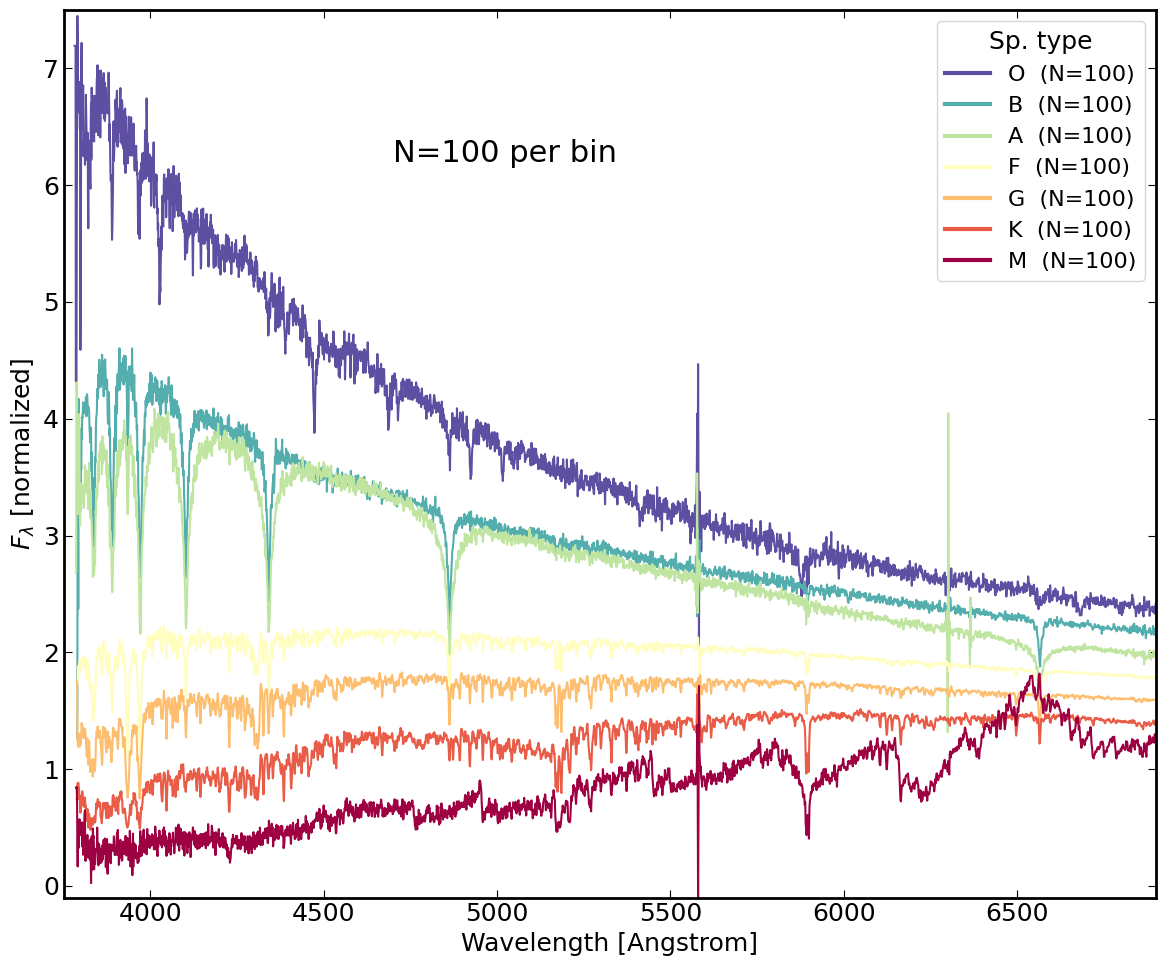

In [18]:
# Figure 2: stacked spectra by spectral type: OBAFGKM (~15 seconds for N=100 per bin)
plot_stacked_spectra_sptype(100)

<a class="anchor" id="galaxies"></a>
# Part II: Galaxies

SDSS has also obtained spectra for millions of galaxies. We now apply the same
spectral stacking technique, binning galaxies by g−r color, which is a good proxy
for their stellar populations:

- **Blue galaxies** (low g−r): star-forming, with young hot stars and emission lines
  (e.g. Hα, [O II], [O III])
- **Red galaxies** (high g−r): quiescent (early-type), dominated by old stellar
  populations and absorption features (e.g. Ca II H&K, the 4000 Å break)

<a class="anchor" id="data_gal"></a>
## Data Retrieval

We select galaxies at low-to-moderate redshift (0.02 ≤ z ≤ 0.2) so that the key
rest-frame optical features fall within the SDSS wavelength coverage, and require
good signal-to-noise in both the g and r bands.


In [19]:
query_gal = """
    SELECT specobjid, z, class, subclass, snmedian,
           spectroflux_g, spectroflux_r, spectroflux_z,
           sn1_g, sn1_r, sn1_i
    FROM sdss_dr17.specobj
    WHERE (class='GALAXY' AND zwarning=0
           AND z BETWEEN 0.02 AND 0.2
           AND instrument='SDSS'
           AND sn1_g > 5 AND sn1_r > 5
           AND spectroflux_g>0 AND spectroflux_r>0 AND spectroflux_z>0)
"""
g = qc.query(sql=query_gal, fmt='table')
print(f"Number of galaxies retrieved: {len(g)}")

# Print first few rows of table
g[:5]

Number of galaxies retrieved: 679784


specobjid,z,class,subclass,snmedian,spectroflux_g,spectroflux_r,spectroflux_z,sn1_g,sn1_r,sn1_i
int64,float64,str6,str21,float64,float64,float64,float64,float64,float64,float64
2124677632158099456,0.044828743,GALAXY,--,3.3544154,3.327516,4.932594,6.4559894,40.7305,45.3734,39.1417
2126838172523456512,0.17661509,GALAXY,STARBURST,8.978089,11.359346,20.142548,33.509468,38.2089,38.0335,33.4987
2721434553318139904,0.14606099,GALAXY,STARFORMING,14.412554,8.440092,26.171173,74.870384,66.9811,64.2539,65.3499
2465885521436502016,0.18190856,GALAXY,--,1.8452535,0.4659644,1.6882766,4.381453,46.3327,60.596,55.2511
1875833682497923072,0.029084004,GALAXY,--,29.409151,36.956707,89.21098,183.4964,51.3858,42.8031,37.9458


In [20]:
# Define g-r and r-z colors
g['g_r'] = -2.5 * np.log10(g['spectroflux_g'] / g['spectroflux_r'])
g['r_z'] = -2.5 * np.log10(g['spectroflux_r'] / g['spectroflux_z'])

r_z_gal = g['r_z']
g_r_gal = g['g_r']

<a class="anchor" id="colors_gal"></a>
## Color-color diagram

We visualize all galaxies in g−r vs. r−z color space. Galaxies form a different locus compared to stars and we define new red lines to the color region that we will select for spectral stacking.

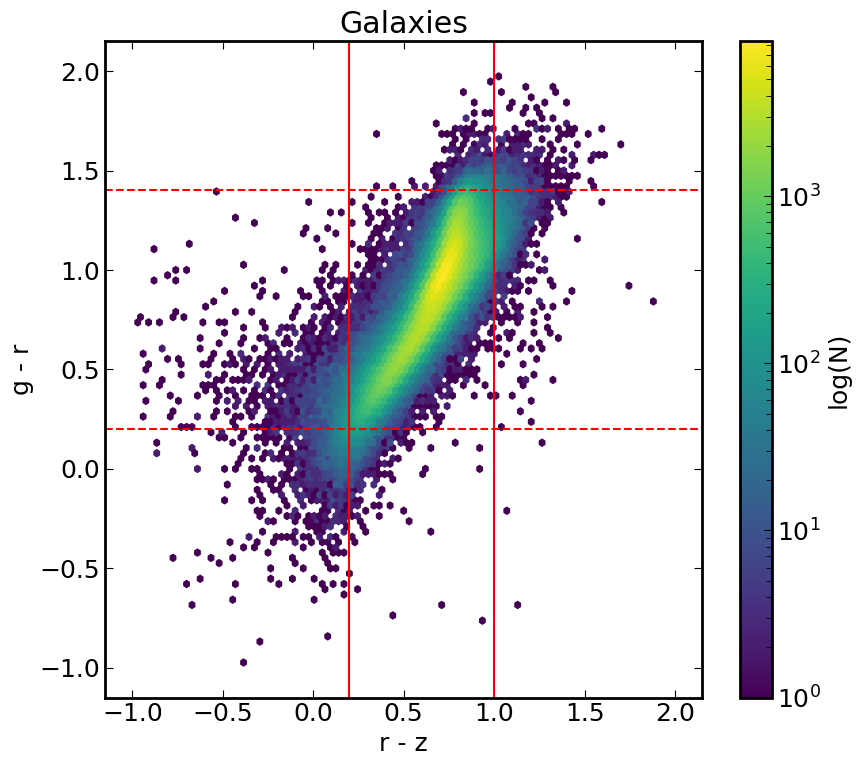

In [21]:
# Galaxy color selection boundaries
r_z_min_gal, r_z_max_gal = 0.2, 1.0
g_r_min_gal, g_r_max_gal = 0.2, 1.4
Nbins_gal = 8
g_r_bin_gal = (g_r_max_gal - g_r_min_gal) / Nbins_gal   # bin width in g-r (in mag)

# Galaxies inside the selection range in r-z (vertical lines)
keep_gal = (r_z_gal >= r_z_min_gal) & (r_z_gal < r_z_max_gal)

fig, ax = plt.subplots(1, 1, figsize=(9, 8))
im = ax.hexbin(r_z_gal, g_r_gal, bins='log', cmap='viridis',
               mincnt=1, extent=(-1, 2, -1, 2))
ax.set_xlabel('r - z')
ax.set_ylabel('g - r')
ax.set_title('Galaxies')

# Mark the selection region
ax.axvline(r_z_min_gal, color='r')
ax.axvline(r_z_max_gal, color='r')
ax.axhline(g_r_min_gal, color='r', ls='--')
ax.axhline(g_r_max_gal, color='r', ls='--')

plt.colorbar(im, label='log(N)')
plt.tight_layout()

<a class="anchor" id="stacking_gal"></a>
## Stacking galaxy spectra

We repeat a similar exercise as with the stellar spectra and stack in 8 bins of g-r color. First, we use a small number of spectra per bin (N=5) and then increase to a significant number to enhance the signal-to-noise ratio and better see the faint continuum features (such as N=200).

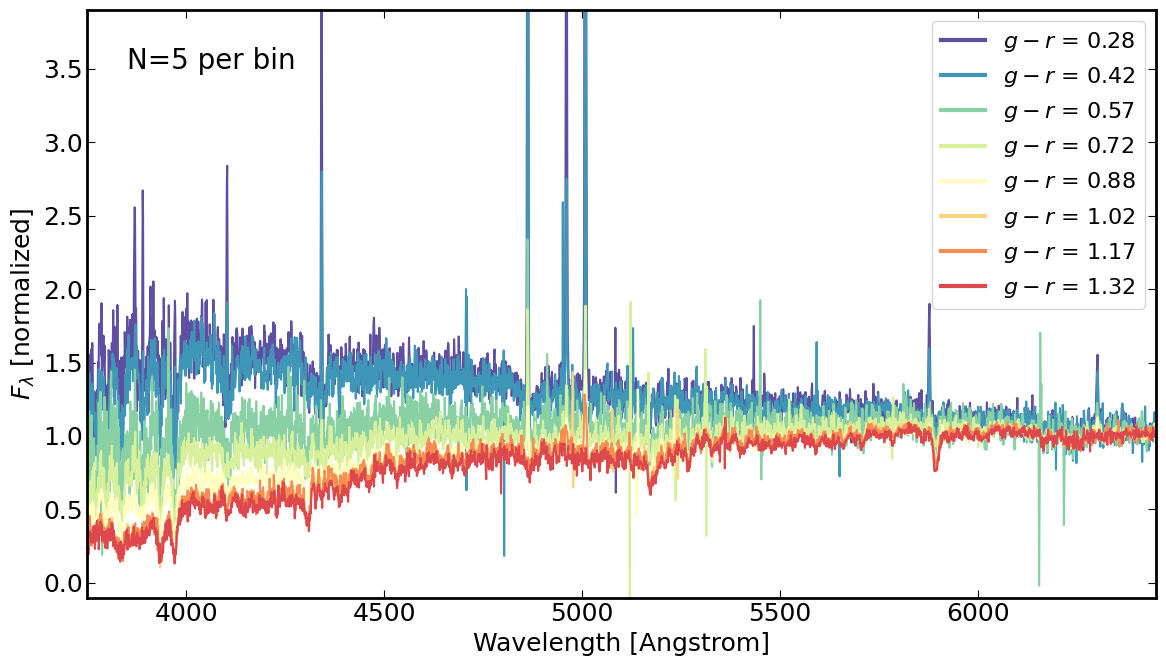

In [22]:
# Galaxies — start with N=5 for a quick view (~3 sec)
plot_stacked_spectra_color(5, tab=g, colors=g_r_gal, color_min=g_r_min_gal,
                           color_max=g_r_max_gal, nbins=Nbins_gal, mask=keep_gal, 
                           xlim=(3750, 6450), ylim=(-0.1, 3.9), x_label=3850, y_label=3.5)

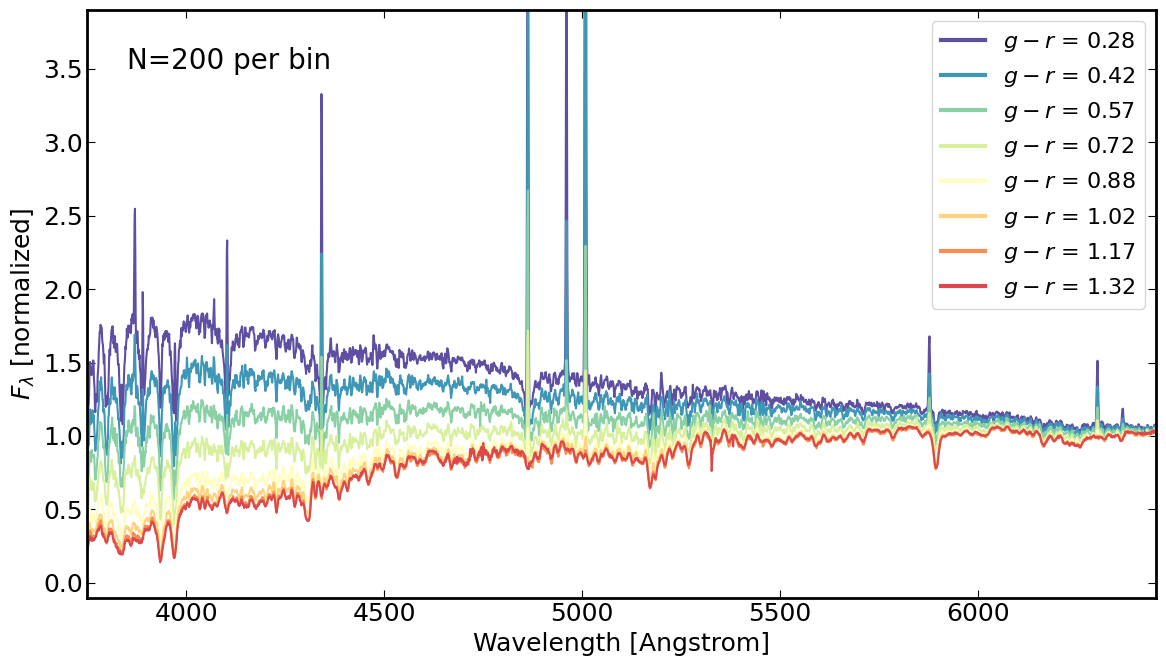

In [23]:
# Galaxies — choose N=200 to obtain higher signal-to-noise ratio (~30 sec)
plot_stacked_spectra_color(200, tab=g, colors=g_r_gal, color_min=g_r_min_gal,
                           color_max=g_r_max_gal, nbins=Nbins_gal, mask=keep_gal,
                           xlim=(3750, 6450), ylim=(-0.1, 3.9), x_label=3850, y_label=3.5)

<a class="anchor" id="resources"></a>
## Resources

- **SPARCL**: https://astrosparcl.datalab.noirlab.edu/sparc/
- **Astro Data Lab**: https://datalab.noirlab.edu/
- **SDSS Spectra Basics**: https://www.sdss4.org/dr17/spectro/spectro_basics/
- **SDSS Spectroscopic Pipeline**: https://www.sdss4.org/dr17/spectro/pipeline/